# Tri automatique des déchets — Entraînement du modèle CNN
**Sujet 11 — Mini-mémoire Deep Learning (M1 IA Data ISM)**

Ce notebook fait tout le pipeline :
1. Récupération et organisation du dataset TrashNet (6 classes)
2. Prétraitement et augmentation de données
3. Modèle par transfert d'apprentissage (MobileNetV2)
4. Entraînement en deux phases (tête seule, puis fine-tuning)
5. Évaluation (matrice de confusion, rapport par classe)
6. Sauvegarde du modèle pour l'outil de démo webcam

## 1. Installation et imports

In [1]:
# Bibliothèques nécessaires (déjà présentes sur Colab pour la plupart)
!pip install -q split-folders

import os
import pathlib
import random
import shutil
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Reproductibilité : on fixe les graines aléatoires
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

ModuleNotFoundError: No module named 'matplotlib'

## 2. Récupération du dataset TrashNet

TrashNet contient 2527 images réparties en 6 classes : `cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`.
On le récupère depuis le dépôt GitHub officiel.

In [ ]:
# Téléchargement du dataset depuis le dépôt GitHub officiel de TrashNet
!git clone -q https://github.com/garythung/trashnet.git

# Les images compressées se trouvent dans trashnet/data/dataset-resized.zip
zip_path = "trashnet/data/dataset-resized.zip"
extract_path = "dataset_brut"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Le zip crée un sous-dossier dataset-resized/ avec les 6 classes
dataset_source = os.path.join(extract_path, "dataset-resized")
print("Classes trouvées :", sorted(os.listdir(dataset_source)))


Classes trouvées : ['.DS_Store', 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 3. Organisation en train / validation / test

On répartit les images : 70% entraînement, 15% validation, 15% test.
On utilise `splitfolders` pour garder une répartition stratifiée simple et reproductible.

In [ ]:
import splitfolders

dataset_split = "dataset_split"

splitfolders.ratio(
    dataset_source,
    output=dataset_split,
    seed=seed,
    ratio=(0.7, 0.15, 0.15)
)

class_names = sorted(os.listdir(os.path.join(dataset_split, "train")))
num_classes = len(class_names)
print("Classes :", class_names)
print("Nombre de classes :", num_classes)

# Comptage des images par classe et par split (utile pour le mémoire, section Données)
for split in ["train", "val", "test"]:
    print(f"\n--- {split} ---")
    for classe in class_names:
        chemin = os.path.join(dataset_split, split, classe)
        print(f"{classe:12s} : {len(os.listdir(chemin))} images")


Copying files: 2527 files [00:00, 4073.35 files/s]

Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre de classes : 6

--- train ---
cardboard    : 282 images
glass        : 350 images
metal        : 287 images
paper        : 415 images
plastic      : 337 images
trash        : 95 images

--- val ---
cardboard    : 60 images
glass        : 75 images
metal        : 61 images
paper        : 89 images
plastic      : 72 images
trash        : 20 images

--- test ---
cardboard    : 61 images
glass        : 76 images
metal        : 62 images
paper        : 90 images
plastic      : 73 images
trash        : 22 images


## 4. Chargement des données et augmentation

On charge les images avec `image_dataset_from_directory`, puis on applique de l'augmentation
(rotation, zoom, flip, luminosité) uniquement sur le train pour améliorer la généralisation.
Important : la préparation des pixels utilise `preprocess_input` de MobileNetV2, pas une simple division par 255.

In [ ]:
img_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_split, "train")
val_dir = os.path.join(dataset_split, "val")
test_dir = os.path.join(dataset_split, "test")

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size,
    label_mode="categorical", shuffle=True, seed=seed
)
val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size,
    label_mode="categorical", shuffle=False
)
test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size,
    label_mode="categorical", shuffle=False
)

# On garde les vrais noms de classes dans l'ordre utilisé par Keras (important pour l'outil final)
class_names = train_data.class_names
print("Ordre des classes utilisé par le modèle :", class_names)

# Couche d'augmentation de données, appliquée seulement à l'entraînement
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="augmentation")

def preparer_train(image, label):
    image = augmentation(image)
    image = preprocess_input(image)
    return image, label

def preparer_eval(image, label):
    image = preprocess_input(image)
    return image, label

train_data = train_data.map(preparer_train).prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(preparer_eval).prefetch(tf.data.AUTOTUNE)
test_data = test_data.map(preparer_eval).prefetch(tf.data.AUTOTUNE)


Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.
Ordre des classes utilisé par le modèle : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 5. Gestion du déséquilibre entre classes

TrashNet n'est pas parfaitement équilibré (ex : peu d'images pour "trash"). On calcule des poids de classe
pour que le modèle ne néglige pas les classes minoritaires.

In [ ]:
# On récupère les labels du dossier train pour calculer les poids de classe
train_labels = []
for classe_index, classe in enumerate(class_names):
    chemin = os.path.join(train_dir, classe)
    train_labels += [classe_index] * len(os.listdir(chemin))

poids_classes = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)
class_weight_dict = dict(enumerate(poids_classes))
print("Poids par classe :", class_weight_dict)


Poids par classe : {0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(3.0982456140350876)}


## 6. Construction du modèle (transfert d'apprentissage — MobileNetV2)

On part d'un MobileNetV2 pré-entraîné sur ImageNet, dont on gèle les poids dans un premier temps.
On ajoute une petite "tête" de classification adaptée à nos 6 classes.

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # on gèle le modèle de base pour la phase 1

entree = layers.Input(shape=(224, 224, 3))
x = base_model(entree, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
sortie = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(entree, sortie, name="tri_dechets_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "tri_dechets_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Phase 1 — Entraînement de la tête (base gelée)

In [ ]:
callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

historique_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5770 - loss: 1.1679 - val_accuracy: 0.7878 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7225 - loss: 0.7486 - val_accuracy: 0.7984 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7622 - loss: 0.6526 - val_accuracy: 0.8276 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7967 - loss: 0.5693 - val_accuracy: 0.8462 - val_loss: 0.4394 - learning_rate: 0.0010
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8222 - loss: 0.5171 - val_accuracy: 0.8382 - val_loss: 0.4663 - learning_rate: 0.0010
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8029 - loss: 0.5067 - val_accuracy: 0.8594 - val_loss: 0.4683 - learning_rate: 0.0010
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8579 - loss: 0.3975 - val_accuracy: 

## 8. Phase 2 — Fine-tuning (dégel partiel du modèle de base)

On dégèle les dernières couches de MobileNetV2 et on continue l'entraînement avec un taux
d'apprentissage beaucoup plus faible, pour affiner sans détruire les poids pré-entraînés.

In [ ]:
base_model.trainable = True

# On ne dégèle que les 30 dernières couches, le reste du réseau reste gelé
for couche in base_model.layers[:-30]:
    couche.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("meilleur_modele.keras", monitor="val_loss", save_best_only=True)
]

historique_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7350 - loss: 0.8000 - val_accuracy: 0.8753 - val_loss: 0.4283
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.7752 - loss: 0.6197 - val_accuracy: 0.8700 - val_loss: 0.4332
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7922 - loss: 0.5778 - val_accuracy: 0.8700 - val_loss: 0.4333
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8035 - loss: 0.5600 - val_accuracy: 0.8674 - val_loss: 0.4343
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7933 - loss: 0.5321 - val_accuracy: 0.8674 - val_loss: 0.4294
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8097 - loss: 0.5068 - val_accuracy: 0.8780 - val_loss: 0.4252
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8171 - loss: 0.5052 - val_accuracy: 0.8753 - val_loss: 0.4209
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8375 - loss: 0.4456 - val_accuracy: 0.8780 - val_loss

## 9. Courbes d'apprentissage (à mettre dans le mémoire, section Résultats)

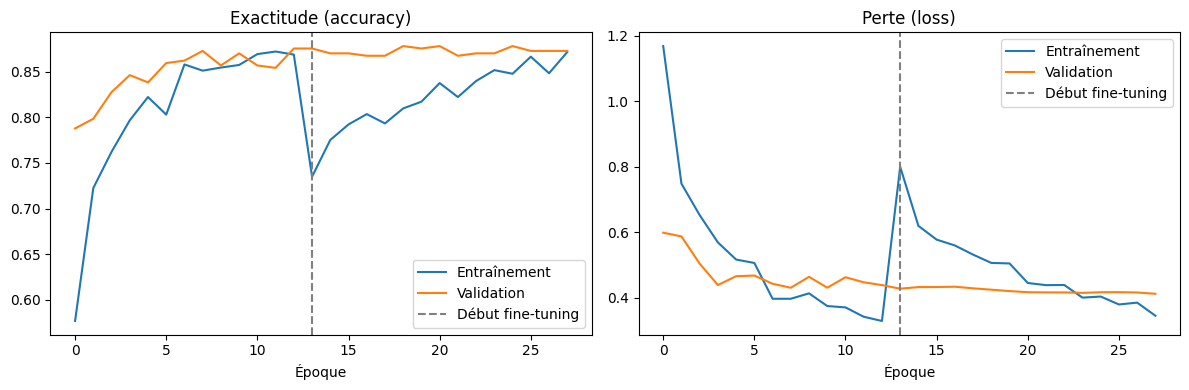

In [ ]:
def fusionner_historiques(h1, h2, cle):
    return h1.history[cle] + h2.history[cle]

accuracy = fusionner_historiques(historique_phase1, historique_phase2, "accuracy")
val_accuracy = fusionner_historiques(historique_phase1, historique_phase2, "val_accuracy")
loss = fusionner_historiques(historique_phase1, historique_phase2, "loss")
val_loss = fusionner_historiques(historique_phase1, historique_phase2, "val_loss")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(accuracy, label="Entraînement")
axes[0].plot(val_accuracy, label="Validation")
axes[0].axvline(x=len(historique_phase1.history["accuracy"]), color="gray", linestyle="--", label="Début fine-tuning")
axes[0].set_title("Exactitude (accuracy)")
axes[0].set_xlabel("Époque")
axes[0].legend()

axes[1].plot(loss, label="Entraînement")
axes[1].plot(val_loss, label="Validation")
axes[1].axvline(x=len(historique_phase1.history["loss"]), color="gray", linestyle="--", label="Début fine-tuning")
axes[1].set_title("Perte (loss)")
axes[1].set_xlabel("Époque")
axes[1].legend()

plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=150)
plt.show()


### 10. Évaluation finale sur le jeu de test

---



In [ ]:
perte_test, exactitude_test = model.evaluate(test_data)
print(f"Exactitude sur le test : {exactitude_test:.2%}")
print(f"Perte sur le test : {perte_test:.4f}")

# Prédictions sur tout le jeu de test pour le rapport détaillé
vraies_classes = []
predictions = []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    predictions.extend(np.argmax(preds, axis=1))
    vraies_classes.extend(np.argmax(labels.numpy(), axis=1))

print("\nRapport de classification :\n")
print(classification_report(vraies_classes, predictions, target_names=class_names))


12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 790ms/step - accuracy: 0.8411 - loss: 0.4934
Exactitude sur le test : 84.11%
Perte sur le test : 0.4934

Rapport de classification :

              precision    recall  f1-score   support

   cardboard       0.96      0.84      0.89        61
       glass       0.84      0.82      0.83        76
       metal       0.76      0.87      0.81        62
       paper       0.88      0.84      0.86        90
     plastic       0.86      0.82      0.84        73
       trash       0.67      0.91      0.77        22

    accuracy                           0.84       384
   macro avg       0.83      0.85      0.83       384
weighted avg       0.85      0.84      0.84       384



## 11. Matrice de confusion (visuel indispensable pour le mémoire)

> Ajouter une citation



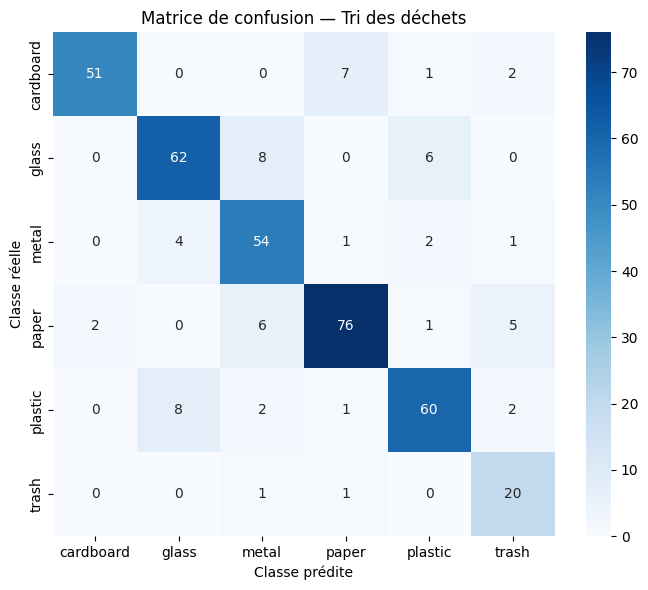

In [ ]:
matrice = confusion_matrix(vraies_classes, predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion — Tri des déchets")
plt.tight_layout()
plt.savefig("matrice_confusion.png", dpi=150)
plt.show()


## 12. Sauvegarde du modèle pour l'outil de démo

On sauvegarde le modèle final et la liste ordonnée des classes (essentielle : l'ordre doit être
identique à celui utilisé pendant l'entraînement pour que les prédictions restent correctes).

In [ ]:
model.save("modele_tri_dechets.keras")

with open("classes.txt", "w") as fichier:
    fichier.write("\n".join(class_names))

print("Modèle sauvegardé : modele_tri_dechets.keras")
print("Classes sauvegardées :", class_names)

# Pense à télécharger ces deux fichiers depuis Colab (icône dossier à gauche)
# et à les placer dans le même dossier que app_webcam.py

Modèle sauvegardé : modele_tri_dechets.keras
Classes sauvegardées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
import time

for images, labels in test_data.take(1):
    images_numpy = images.numpy()
    break

_ = model.predict(images_numpy[:1], verbose=0)  # échauffement

temps_par_image = []
n_mesures = 100
for i in range(n_mesures):
    image_unique = images_numpy[i % len(images_numpy)][np.newaxis, ...]
    debut = time.time()
    _ = model.predict(image_unique, verbose=0)
    fin = time.time()
    temps_par_image.append((fin - debut) * 1000)

latence_moyenne = np.mean(temps_par_image)
latence_ecart_type = np.std(temps_par_image)
fps = 1000 / latence_moyenne

print(f"Latence moyenne : {latence_moyenne:.1f} ms (± {latence_ecart_type:.1f} ms)")
print(f"Débit : {fps:.1f} images/seconde")

Latence moyenne : 95.5 ms (± 44.9 ms)
Débit : 10.5 images/seconde


In [ ]:
def construire_modele():
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    base.trainable = False
    entree = layers.Input(shape=(224, 224, 3))
    x = base(entree, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    sortie = layers.Dense(num_classes, activation="softmax")(x)
    m = models.Model(entree, sortie)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               loss="categorical_crossentropy", metrics=["accuracy"])
    return m

# --- Variante 1 : SANS pondération de classe ---
modele_sans_poids = construire_modele()
modele_sans_poids.fit(
    train_data, validation_data=val_data, epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)
_, exactitude_sans_poids = modele_sans_poids.evaluate(test_data)

# --- Variante 2 : SANS fine-tuning (tête seule, base gelée) ---
modele_sans_finetuning = construire_modele()
modele_sans_finetuning.fit(
    train_data, validation_data=val_data, epochs=10,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)
_, exactitude_sans_finetuning = modele_sans_finetuning.evaluate(test_data)

print("Récapitulatif :")
print(f"  Modèle complet (référence)   : 83.6%")
print(f"  Sans class_weight            : {exactitude_sans_poids:.1%}")
print(f"  Sans fine-tuning (tête seule) : {exactitude_sans_finetuning:.1%}")

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5883 - loss: 1.0696 - val_accuracy: 0.8037 - val_loss: 0.5603
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7429 - loss: 0.6919 - val_accuracy: 0.8276 - val_loss: 0.5024
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.7775 - loss: 0.6006 - val_accuracy: 0.8276 - val_loss: 0.4813
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8148 - loss: 0.5253 - val_accuracy: 0.8037 - val_loss: 0.5541
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8267 - loss: 0.4767 - val_accuracy: 0.8355 - val_loss: 0.5093
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8426 - loss: 0.4460 - val_accuracy: 0.8408 - val_loss: 0.4578
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8499 - loss: 0.4147 - val_accuracy: 0.8435 - val_loss: 0.4600
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8511 - loss: 0.3995 - val_accuracy: 0.8435 - val_loss: